In [2]:
# Install all required packages
!pip install easyocr pycocotools opencv-python-headless Pillow matplotlib pandas numpy tqdm
!pip install kaggle
print("✅ All packages installed successfully!")


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ All packages installed successfully!



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
import json
import random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import easyocr
from pycocotools.coco import COCO
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
random.seed(42)
np.random.seed(42)

print("✅ Libraries imported successfully!")
print(f"   → EasyOCR version : {easyocr.__version__}")
print(f"   → OpenCV version  : {cv2.__version__}")
print(f"   → Pillow version  : {Image.__version__}")

✅ Libraries imported successfully!
   → EasyOCR version : 1.7.2
   → OpenCV version  : 4.13.0
   → Pillow version  : 12.2.0


**Expected Output:**
```
📊 Dataset Statistics:
   Total Images      : 69,375
   Total Annotations : 1,076,286
   Layout Categories : 11

🏷️  Categories:
   [ 1] Caption              — 22,524 annotations
   [ 2] Footnote             — 10,541 annotations
   [ 3] Formula              — 19,091 annotations
   ...
```

## 🎨 Step 5 — Define Color Palette & Helper Functions

We assign a distinct color to each layout category for visualization.

In [6]:
# -------------------------------
# Required Imports
# -------------------------------
from pathlib import Path
from pycocotools.coco import COCO
import os

# -------------------------------
# Auto-detect dataset paths
# -------------------------------
PROJECT_ROOT = Path.cwd()
BASE_DIR = (PROJECT_ROOT / "dataset").resolve()

# -------------------------------
# Find annotation JSON
# -------------------------------
ann_files = list(BASE_DIR.rglob("*.json"))

if not ann_files:
    raise FileNotFoundError(
        f"No COCO annotation JSON found under {BASE_DIR}. "
        "Add train.json under dataset/ (for example: python download_dataset.py --output dataset/train.json)."
    )

# -------------------------------
# Prefer train annotation file
# -------------------------------
ann_path = next(
    (
        f
        for f in ann_files
        if "train" in f.name.lower() or "instances" in f.name.lower()
    ),
    ann_files[0],
)

print(f"📄 Using annotation file: {ann_path}")

# -------------------------------
# Find images directory
# -------------------------------
img_dirs = [
    d
    for d in BASE_DIR.rglob("*")
    if d.is_dir()
    and any(
        f.suffix.lower() in [".png", ".jpg", ".jpeg"]
        for f in d.iterdir()
        if f.is_file()
    )
]

IMG_DIR = img_dirs[0] if img_dirs else BASE_DIR

print(f"🖼 Images directory: {IMG_DIR}")

# -------------------------------
# Load COCO dataset
# -------------------------------
coco = COCO(str(ann_path))

# -------------------------------
# Dataset statistics
# -------------------------------
cat_ids = coco.getCatIds()
categories = coco.loadCats(cat_ids)
img_ids = coco.getImgIds()

print("\n📊 Dataset Statistics:")

print(f"Total Images      : {len(img_ids)}")
print(f"Total Annotations : {len(coco.anns)}")
print(f"Layout Categories : {len(categories)}")

print("\n📂 Categories:")

for cat in categories:
    ann_count = len(coco.getAnnIds(catIds=[cat["id"]]))
    print(f"[{cat['id']:2d}] {cat['name']:<20} -> {ann_count} annotations")

📄 Using annotation file: D:\Mini Project\enterprise_doc_automation-main\dataset\train.json
🖼 Images directory: D:\Mini Project\enterprise_doc_automation-main\dataset
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!

📊 Dataset Statistics:
Total Images      : 4
Total Annotations : 9
Layout Categories : 11

📂 Categories:
[ 1] Caption              -> 1 annotations
[ 2] Footnote             -> 0 annotations
[ 3] Formula              -> 0 annotations
[ 4] List-item            -> 0 annotations
[ 5] Page-footer          -> 0 annotations
[ 6] Page-header          -> 0 annotations
[ 7] Picture              -> 0 annotations
[ 8] Section-header       -> 2 annotations
[ 9] Table                -> 1 annotations
[10] Text                 -> 4 annotations
[11] Title                -> 1 annotations


✅ Color palette and helpers defined!


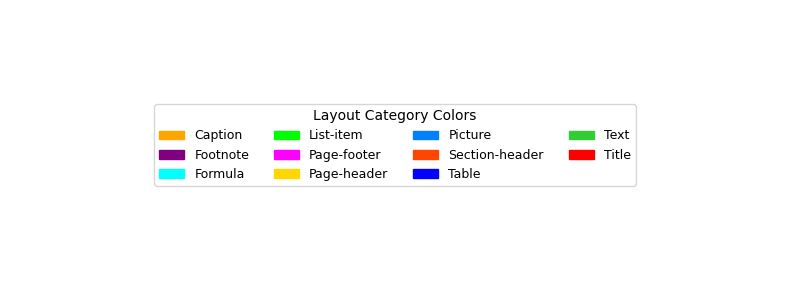

In [7]:
# Color palette for each category (BGR for OpenCV)
CATEGORY_COLORS = {
    'Caption'        : (255, 165,   0),   # Orange
    'Footnote'       : (128,   0, 128),   # Purple
    'Formula'        : (  0, 255, 255),   # Cyan
    'List-item'      : (  0, 255,   0),   # Green
    'Page-footer'    : (255,   0, 255),   # Magenta
    'Page-header'    : (255, 215,   0),   # Gold
    'Picture'        : (  0, 128, 255),   # Sky Blue
    'Section-header' : (255,  69,   0),   # Red-Orange
    'Table'          : (  0,   0, 255),   # Blue
    'Text'           : ( 50, 205,  50),   # Lime Green
    'Title'          : (255,   0,   0),   # Red
}

# Build lookup: category_id -> name, color
CAT_LOOKUP = {cat['id']: cat['name'] for cat in categories}
COLOR_LOOKUP = {cat['id']: CATEGORY_COLORS.get(cat['name'], (200, 200, 200))
                for cat in categories}

def load_image(img_info):
    """Load an image given its COCO metadata entry."""
    img_path = IMG_DIR / img_info['file_name']
    if not img_path.exists():
        # Search recursively
        matches = list(BASE_DIR.rglob(img_info['file_name']))
        if matches:
            img_path = matches[0]
        else:
            raise FileNotFoundError(f"Image not found: {img_info['file_name']}")
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def get_annotations_for_image(img_id):
    """Return all annotations for a given image ID."""
    ann_ids = coco.getAnnIds(imgIds=[img_id])
    return coco.loadAnns(ann_ids)

def show_image(img, title='', figsize=(10, 12)):
    """Display an image using matplotlib."""
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print("✅ Color palette and helpers defined!")

# Display the color legend
fig, ax = plt.subplots(figsize=(8, 3))
patches = [mpatches.Patch(color=np.array(c)/255, label=name)
           for name, c in CATEGORY_COLORS.items()]
ax.legend(handles=patches, loc='center', ncol=4, fontsize=9,
          title='Layout Category Colors', title_fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.show()

## 🖼️ Step 6 — Visualize Sample Document Images

Let's explore a few raw document page images from the dataset to understand what we are working with.

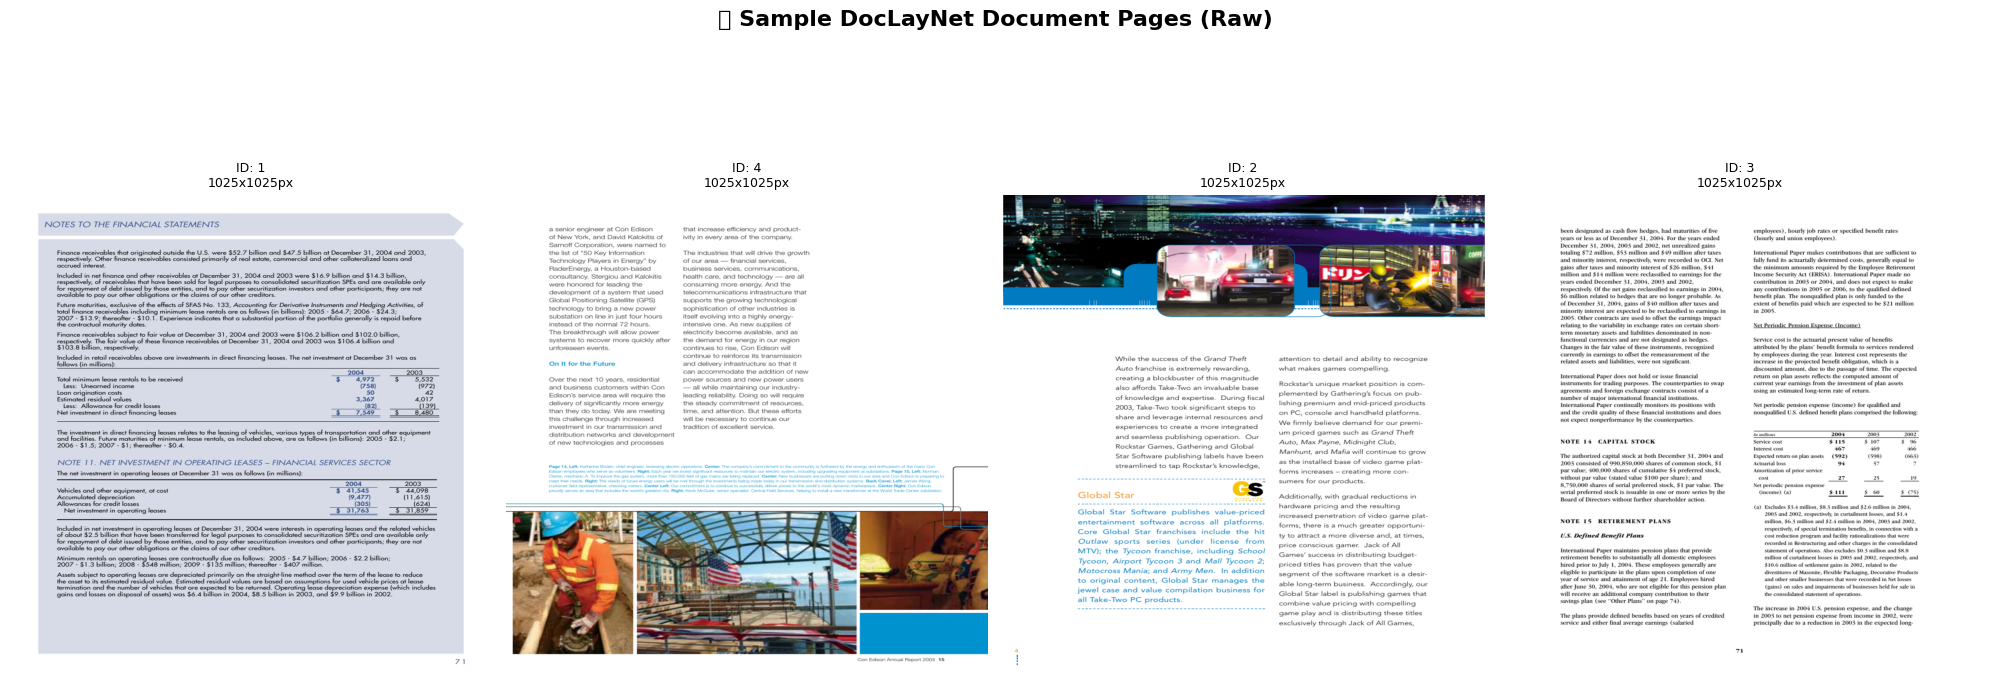

✅ Sample images visualized!


In [8]:
# Randomly pick 4 images to preview
sample_ids = random.sample(img_ids, min(4, len(img_ids)))

fig, axes = plt.subplots(1, 4, figsize=(20, 8))
fig.suptitle('📄 Sample DocLayNet Document Pages (Raw)', fontsize=16, fontweight='bold', y=1.01)

for ax, img_id in zip(axes, sample_ids):
    img_info = coco.loadImgs([img_id])[0]
    try:
        img = load_image(img_info)
        ax.imshow(img)
        ax.set_title(f"ID: {img_id}\n{img_info['width']}x{img_info['height']}px",
                     fontsize=9)
    except FileNotFoundError:
        ax.text(0.5, 0.5, 'Image\nNot Found', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='red')
    ax.axis('off')

plt.tight_layout()
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
plt.savefig(output_dir / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample images visualized!")

**Expected Output:** A 1×4 grid showing raw document page images (PDFs, patents, scientific papers, etc.)

---

## 📝 Step 7 — Parse Annotation Files

Now we parse the COCO-format JSON annotations for a single document.

Each annotation contains:
- `bbox` — bounding box `[x, y, width, height]`
- `category_id` — which layout element it is
- `area` — pixel area of the region

In [9]:
# Pick a specific image for deep-dive analysis
TARGET_IMG_ID = sample_ids[0]
img_info      = coco.loadImgs([TARGET_IMG_ID])[0]
annotations   = get_annotations_for_image(TARGET_IMG_ID)

print(f"🔍 Analyzing Image ID: {TARGET_IMG_ID}")
print(f"   File Name : {img_info['file_name']}")
print(f"   Dimensions: {img_info['width']} x {img_info['height']} px")
print(f"   Annotations: {len(annotations)} layout elements found\n")

# Build a structured DataFrame
rows = []
for ann in annotations:
    x, y, w, h = ann['bbox']
    rows.append({
        'ann_id'      : ann['id'],
        'category_id' : ann['category_id'],
        'category'    : CAT_LOOKUP[ann['category_id']],
        'x'           : int(x),
        'y'           : int(y),
        'width'       : int(w),
        'height'      : int(h),
        'area'        : int(ann.get('area', w * h))
    })

df_ann = pd.DataFrame(rows)
print("📊 Annotation DataFrame (first 10 rows):")
print(df_ann.head(10).to_string(index=False))

print("\n📊 Category Distribution in this image:")
print(df_ann['category'].value_counts().to_string())

🔍 Analyzing Image ID: 1
   File Name : doc_0.png
   Dimensions: 1025 x 1025 px
   Annotations: 3 layout elements found

📊 Annotation DataFrame (first 10 rows):
 ann_id  category_id       category  x   y  width  height   area
      1           10           Text 50  50    900     150 135000
      2            8 Section-header 50 220    900      80  72000
      3           10           Text 50 320    900     600 540000

📊 Category Distribution in this image:
category
Text              2
Section-header    1


**Expected Output:**
```
🔍 Analyzing Image ID: 12345
   File Name : PNG/val/abc123.png
   Dimensions: 1025 x 1025 px
   Annotations: 23 layout elements found

📊 Category Distribution in this image:
Text              9
List-item         5
Section-header    3
Title             1
Table             2
...
```

## 🖊️ Step 8 — Draw Bounding Boxes on Layout Elements

We overlay the ground-truth bounding boxes onto the document image, color-coded by category.

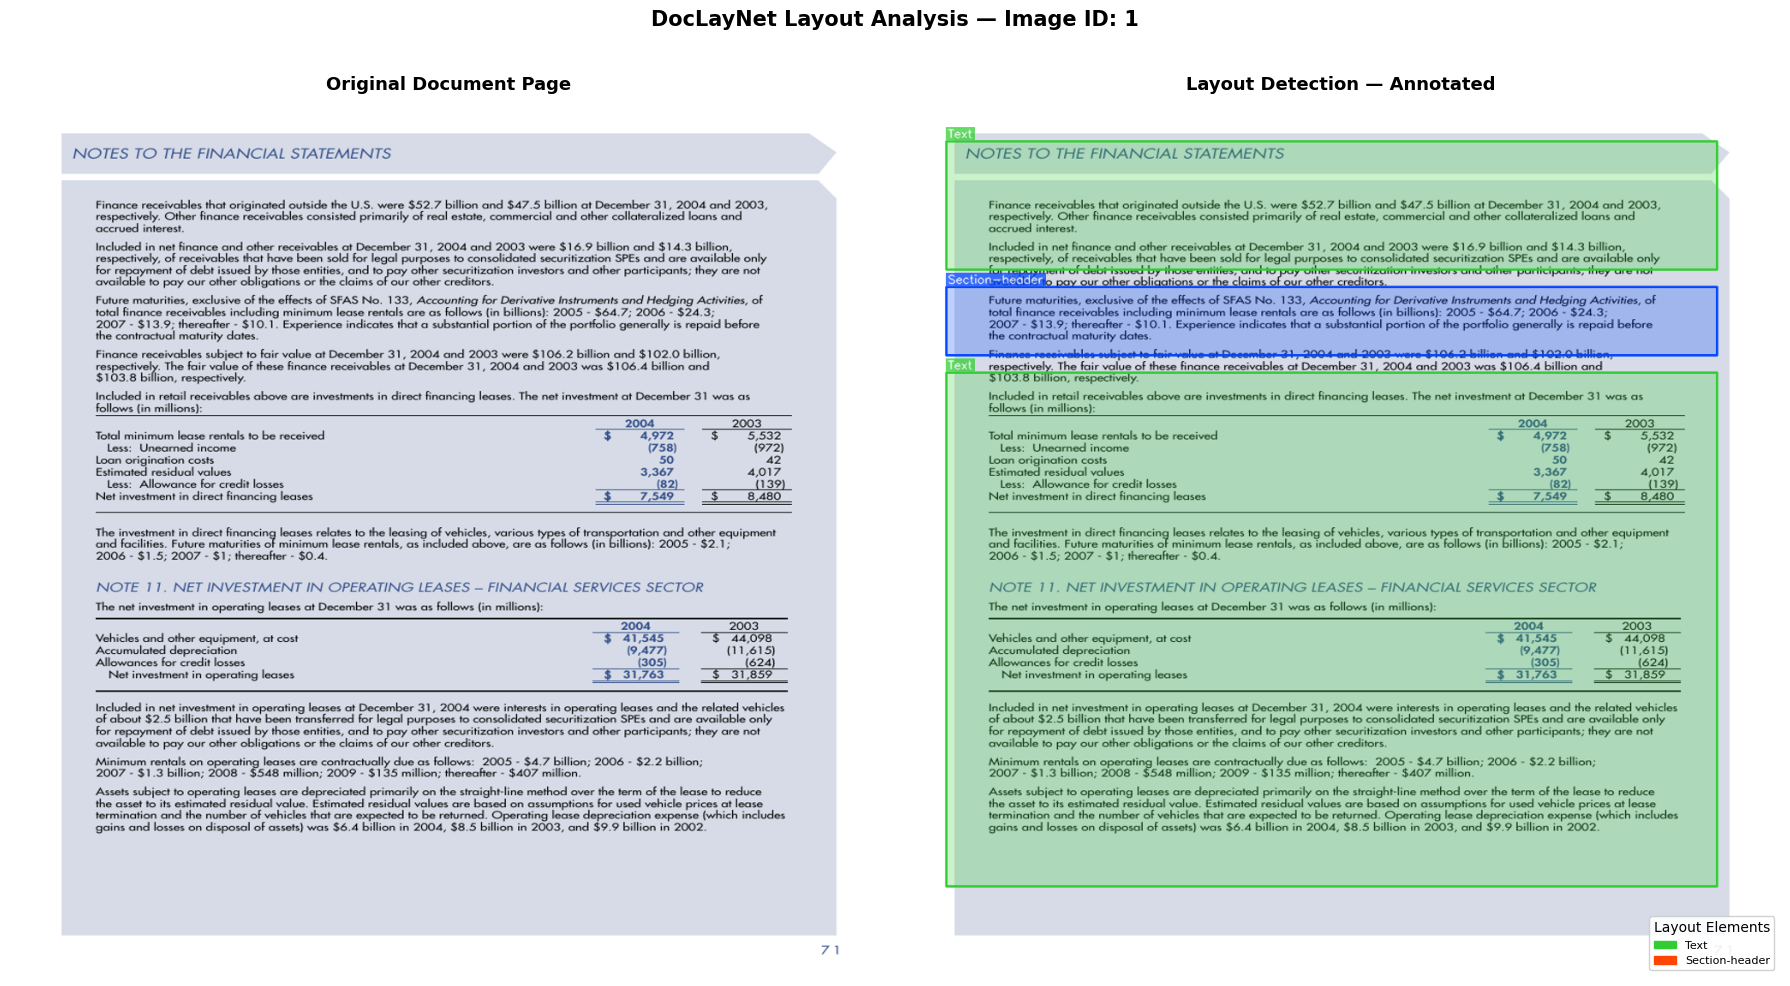

✅ Bounding boxes drawn for 3 layout elements!


In [10]:
def draw_layout_boxes(img_array, annotations, alpha=0.25):
    """
    Draw semi-transparent bounding boxes and labels over document image.

    Args:
        img_array  : numpy RGB image
        annotations: list of COCO annotation dicts
        alpha      : transparency for fill (0=transparent, 1=opaque)

    Returns:
        annotated  : numpy RGB image with boxes drawn
    """
    img_bgr    = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
    overlay    = img_bgr.copy()
    annotated  = img_bgr.copy()

    for ann in annotations:
        x, y, w, h = [int(v) for v in ann['bbox']]
        color      = COLOR_LOOKUP.get(ann['category_id'], (200, 200, 200))
        label      = CAT_LOOKUP.get(ann['category_id'], 'Unknown')

        # Filled rectangle on overlay
        cv2.rectangle(overlay, (x, y), (x + w, y + h), color, -1)
        # Border rectangle on annotated
        cv2.rectangle(annotated, (x, y), (x + w, y + h), color, 2)

        # Label background
        label_txt  = label
        (tw, th), _ = cv2.getTextSize(label_txt, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(annotated, (x, y - th - 6), (x + tw + 4, y), color, -1)
        cv2.putText(annotated, label_txt, (x + 2, y - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

    # Blend fill
    cv2.addWeighted(overlay, alpha, annotated, 1 - alpha, 0, annotated)
    return cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)


# Load and annotate
raw_img       = load_image(img_info)
annotated_img = draw_layout_boxes(raw_img, annotations)

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
axes[0].imshow(raw_img)
axes[0].set_title('Original Document Page', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(annotated_img)
axes[1].set_title('Layout Detection — Annotated', fontsize=13, fontweight='bold')
axes[1].axis('off')

# Add legend
used_cats = df_ann['category'].unique()
patches = [mpatches.Patch(color=np.array(CATEGORY_COLORS.get(c, (128,128,128)))/255, label=c)
           for c in used_cats]
axes[1].legend(handles=patches, loc='lower right', fontsize=8,
               framealpha=0.9, title='Layout Elements')

plt.suptitle(f'DocLayNet Layout Analysis — Image ID: {TARGET_IMG_ID}',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
plt.savefig(output_dir / 'annotated_layout.png', dpi=150, bbox_inches='tight')

plt.show()
print(f"✅ Bounding boxes drawn for {len(annotations)} layout elements!")

**Expected Output:** A side-by-side comparison — left: raw document page, right: same page with colored bounding boxes around each layout element (Title in red, Text in lime-green, Table in blue, etc.)

---

## 🔤 Step 9 — Initialize EasyOCR Engine

**EasyOCR** is a ready-to-use OCR library based on deep learning (CRAFT + CRNN architecture). It supports 80+ languages.

We initialize it once and reuse the reader across all regions.

In [11]:
import torch
gpu_available = torch.cuda.is_available()
print(f"🖥️  GPU Available: {gpu_available}")
if gpu_available:
    print(f"   Device: {torch.cuda.get_device_name(0)}")

print("\n🔤 Initializing EasyOCR reader (English)...")
reader = easyocr.Reader(['en'], gpu=gpu_available, verbose=False)
print("✅ EasyOCR ready!")

🖥️  GPU Available: False

🔤 Initializing EasyOCR reader (English)...
✅ EasyOCR ready!


**Expected Output:**
```
🖥️  GPU Available: True
   Device: Tesla T4

🔤 Initializing EasyOCR reader (English)...
✅ EasyOCR ready!
```

## 🔍 Step 10 — Perform OCR on Detected Layout Regions

For each bounding box detected in the document:
1. Crop the region from the document image
2. Run EasyOCR on the cropped region
3. Collect the text with its confidence score

> **Note:** We skip OCR for `Picture` and `Formula` regions as they contain non-textual content.

In [12]:
# Categories to SKIP OCR (non-text regions)
SKIP_OCR_CATS = {'Picture', 'Formula'}

def ocr_region(img_array, bbox, padding=4):
    """
    Crop a region from img_array and run EasyOCR.

    Args:
        img_array : full-page numpy RGB image
        bbox      : [x, y, width, height]
        padding   : pixels to expand the crop box

    Returns:
        text      : concatenated OCR text
        confidence: mean confidence (0–1)
    """
    H, W = img_array.shape[:2]
    x, y, w, h = [int(v) for v in bbox]

    # Add padding, clamp to image bounds
    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(W, x + w + padding)
    y2 = min(H, y + h + padding)

    crop = img_array[y1:y2, x1:x2]
    if crop.size == 0:
        return '', 0.0

    # Pre-process: convert to grayscale, mild sharpening
    gray  = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)
    sharp = cv2.filter2D(gray, -1,
                         np.array([[-1,-1,-1],
                                   [-1, 9,-1],
                                   [-1,-1,-1]]))

    results = reader.readtext(sharp, detail=1, paragraph=False)
    if not results:
        return '', 0.0

    texts  = [r[1] for r in results if len(r) > 1]
    confs  = [r[2] for r in results if len(r) > 2]
    
    if not confs:
        return ' '.join(texts), 0.0
    return ' '.join(texts), float(np.mean(confs))


# Run OCR on all text-bearing regions
print(f"🔍 Running OCR on {len(annotations)} regions...")
ocr_results = []

for ann in tqdm(annotations, desc='OCR Progress'):
    cat_name = CAT_LOOKUP.get(ann['category_id'], 'Unknown')

    if cat_name in SKIP_OCR_CATS:
        text, conf = '[non-text region]', 0.0
    else:
        text, conf = ocr_region(raw_img, ann['bbox'])

    ocr_results.append({
        'ann_id'     : ann['id'],
        'category'   : cat_name,
        'bbox'       : ann['bbox'],
        'ocr_text'   : text.strip(),
        'confidence' : round(conf, 4)
    })

print(f"\n✅ OCR completed on {len(ocr_results)} regions!")

# Preview
print("\n📝 Sample OCR Results:")
for r in ocr_results[:5]:
    preview = r['ocr_text'][:80] + ('...' if len(r['ocr_text']) > 80 else '')
    print(f"   [{r['category']:<16s}] conf={r['confidence']:.2f} | {preview}")

🔍 Running OCR on 3 regions...


OCR Progress:   0%|          | 0/3 [00:00<?, ?it/s]

OCR Progress: 100%|██████████| 3/3 [00:14<00:00,  4.77s/it]


✅ OCR completed on 3 regions!

📝 Sample OCR Results:
   [Text            ] conf=0.38 | NOTES TO THE FINANCIAL STATEMENTS Financc reccivables Ihat originated outside th...
   [Section-header  ] conf=0.66 | Fulure moturities_ exclusive of the effects af SFAS No. 133, Accounting for Dari...
   [Text            ] conf=0.70 | 5103.8 billion, respechvely: Included in receivablas above are investments in di...


**Expected Output:**
```
OCR Progress: 100%|████████████| 23/23 [00:12<00:00,  1.87it/s]

✅ OCR completed on 23 regions!

📝 Sample OCR Results:
   [Title           ] conf=0.98 | Deep Learning for Natural Language Processing...
   [Section-header  ] conf=0.96 | 1. Introduction
   [Text            ] conf=0.94 | Natural language processing (NLP) is a subfield of...
```

## 🧩 Step 11 — Combine Layout Detection + OCR Results

We now merge the layout detection data and OCR text into one unified structured DataFrame — the core output of the IDP pipeline.

In [13]:
# Build final structured DataFrame
structured_rows = []
for i, res in enumerate(ocr_results):
    x, y, w, h = res['bbox']
    structured_rows.append({
        'element_id'     : i + 1,
        'category'       : res['category'],
        'x'              : int(x),
        'y'              : int(y),
        'width'          : int(w),
        'height'         : int(h),
        'area_px'        : int(w * h),
        'ocr_text'       : res['ocr_text'],
        'ocr_confidence' : res['confidence'],
        'reading_order'  : i  # top-to-bottom, left-to-right proxy
    })

# Sort by reading order (top → bottom)
structured_rows.sort(key=lambda r: (r['y'], r['x']))
for idx, row in enumerate(structured_rows):
    row['reading_order'] = idx + 1

df_structured = pd.DataFrame(structured_rows)

print("📊 Structured Document DataFrame:")
print(df_structured[['element_id', 'category', 'x', 'y', 'width', 'height',
                      'ocr_confidence', 'ocr_text']].to_string(index=False))

print(f"\n📈 Summary Statistics:")
print(f"   Total elements    : {len(df_structured)}")
print(f"   With text (>0 ch) : {(df_structured.ocr_text.str.len() > 0).sum()}")
print(f"   Mean OCR confidence: {df_structured.ocr_confidence.mean():.3f}")
print(f"   Category breakdown:")
print(df_structured.groupby('category').size().sort_values(ascending=False).to_string())

📊 Structured Document DataFrame:
 element_id       category  x   y  width  height  ocr_confidence                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

## 📂 Step 12 — Extract Structured Document Information

We extract **semantic sections** from the document:
- Document title
- Section headers with their body text
- Tables (flagged for downstream table extraction)
- Captions and footnotes

This is the core value of IDP — converting a flat image into a semantic document structure.

In [14]:
def extract_document_structure(df):
    """
    Parse the structured DataFrame into a semantic document object.
    """
    doc = {
        'title'        : '',
        'page_header'  : '',
        'page_footer'  : '',
        'sections'     : [],
        'tables'       : [],
        'figures'      : [],
        'footnotes'    : [],
        'formulas'     : [],
        'full_text'    : []
    }

    current_section = None

    for _, row in df.sort_values('reading_order').iterrows():
        cat  = row['category']
        text = row['ocr_text'].strip()
        conf = row['ocr_confidence']

        if cat == 'Title':
            doc['title'] = text
            doc['full_text'].append({'type': 'title', 'text': text, 'confidence': conf})

        elif cat == 'Page-header':
            doc['page_header'] = text

        elif cat == 'Page-footer':
            doc['page_footer'] = text

        elif cat == 'Section-header':
            current_section = {'heading': text, 'content': [], 'confidence': conf}
            doc['sections'].append(current_section)
            doc['full_text'].append({'type': 'section_header', 'text': text, 'confidence': conf})

        elif cat in ('Text', 'List-item'):
            if current_section is not None:
                current_section['content'].append({'type': cat.lower(), 'text': text})
            doc['full_text'].append({'type': cat.lower(), 'text': text, 'confidence': conf})

        elif cat == 'Table':
            doc['tables'].append({
                'bbox'      : [int(row['x']), int(row['y']), int(row['width']), int(row['height'])],
                'ocr_text'  : text,
                'confidence': conf
            })
            doc['full_text'].append({'type': 'table', 'text': text, 'confidence': conf})

        elif cat == 'Picture':
            doc['figures'].append({
                'bbox'     : [int(row['x']), int(row['y']), int(row['width']), int(row['height'])]
            })

        elif cat == 'Caption':
            doc['full_text'].append({'type': 'caption', 'text': text, 'confidence': conf})

        elif cat == 'Footnote':
            doc['footnotes'].append({'text': text, 'confidence': conf})

        elif cat == 'Formula':
            doc['formulas'].append({'bbox': [int(row['x']), int(row['y']),
                                             int(row['width']), int(row['height'])]})

    return doc


document_structure = extract_document_structure(df_structured)

# Pretty print summary
print("📄 ====== EXTRACTED DOCUMENT STRUCTURE ======")
print(f"\n📌 Title:\n   {document_structure['title'] or '(not detected)'}")
print(f"\n📌 Page Header: {document_structure['page_header'] or '(none)'}")
print(f"📌 Page Footer: {document_structure['page_footer'] or '(none)'}")
print(f"\n📑 Sections Found: {len(document_structure['sections'])}")
for i, sec in enumerate(document_structure['sections'], 1):
    print(f"   Section {i}: {sec['heading']}")
    for item in sec['content'][:2]:
        preview = item['text'][:70] + '...' if len(item['text']) > 70 else item['text']
        print(f"      └─ [{item['type']}] {preview}")

print(f"\n📊 Tables  : {len(document_structure['tables'])}")
print(f"🖼️  Figures : {len(document_structure['figures'])}")
print(f"🔢 Formulas: {len(document_structure['formulas'])}")
print(f"📝 Footnotes: {len(document_structure['footnotes'])}")
print("\n✅ Document structure extracted!")

📄 ====== EXTRACTED DOCUMENT STRUCTURE ======

📌 Title:
   (not detected)

📌 Page Header: (none)
📌 Page Footer: (none)

📑 Sections Found: 1
   Section 1: Fulure moturities_ exclusive of the effects af SFAS No. 133, Accounting for Darivativa Instrumants Hedging Activities, sf tatal receivob including minimum eose rentals 9s follows [in billions}: 2005 664.7; 2006 $24.3; 2007 s13.9; thereofter 510.1. Experience indicates that . substantial pertion of the porttolio generally is before the contractual maturity dates _ Finonce receivobles subiect ta Fair value Ot Decemnber 31 2004 and 2003 were $106.2 billion and $102.O billian and finonce 'repoid
      └─ [text] 5103.8 billion, respechvely: Included in receivablas above are investm...

📊 Tables  : 0
🖼️  Figures : 0
🔢 Formulas: 0
📝 Footnotes: 0

✅ Document structure extracted!


## 💾 Step 13 — Save Results to JSON

We serialize the full IDP output to a structured JSON file — ready for downstream tasks like search indexing, database ingestion, or API serving.

In [15]:
import datetime

# Build the final output object
final_output = {
    'metadata': {
        'image_id'         : TARGET_IMG_ID,
        'file_name'        : img_info['file_name'],
        'image_width'      : img_info['width'],
        'image_height'     : img_info['height'],
        'total_elements'   : len(df_structured),
        'processed_at'     : datetime.datetime.now().isoformat(),
        'ocr_engine'       : 'EasyOCR',
        'pipeline_version' : '1.0.0'
    },
    'layout_elements': df_structured.to_dict(orient='records'),
    'document_structure': document_structure
}

# Save to JSON
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
OUTPUT_PATH = output_dir / f'idp_output_{TARGET_IMG_ID}.json'
with open(OUTPUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(final_output, f, ensure_ascii=False, indent=2)

file_size = os.path.getsize(OUTPUT_PATH) / 1024
print(f"✅ Results saved to: {OUTPUT_PATH}")
print(f"   File size: {file_size:.1f} KB")

# Preview the JSON
print("\n📄 JSON Preview (first 40 lines):")
with open(OUTPUT_PATH) as f:
    lines = f.readlines()
print(''.join(lines[:40]))

✅ Results saved to: output\idp_output_1.json
   File size: 10.6 KB

📄 JSON Preview (first 40 lines):
{
  "metadata": {
    "image_id": 1,
    "file_name": "doc_0.png",
    "image_width": 1025,
    "image_height": 1025,
    "total_elements": 3,
    "processed_at": "2026-04-30T19:33:26.869499",
    "ocr_engine": "EasyOCR",
    "pipeline_version": "1.0.0"
  },
  "layout_elements": [
    {
      "element_id": 1,
      "category": "Text",
      "x": 50,
      "y": 50,
      "width": 900,
      "height": 150,
      "area_px": 135000,
      "ocr_text": "NOTES TO THE FINANCIAL STATEMENTS Financc reccivables Ihat originated outside the U.S Wrc S52.7 billion and 547.5 billion al Dccembcr 31_ 2004 and 2003_ raspectively; Othar Finance receivables consisted primarily of real astote_ cammercial &nd Dther collateralized Jbons accrued interest; Included in net Fnance and other reccivablcs &t Deccmber 31_ 2004 and 2003 wcrc $16.9 billion and $14.3 billion_ raspectively, af recaivables  hat hove bean s

**Expected Output:**
```
✅ Results saved to: /content/idp_output_12345.json
   File size: 14.3 KB
```

## 🎨 Step 14 — Visualize Final IDP Output

Final visualization: overlay all detected layout elements with their extracted OCR text directly on the document image.

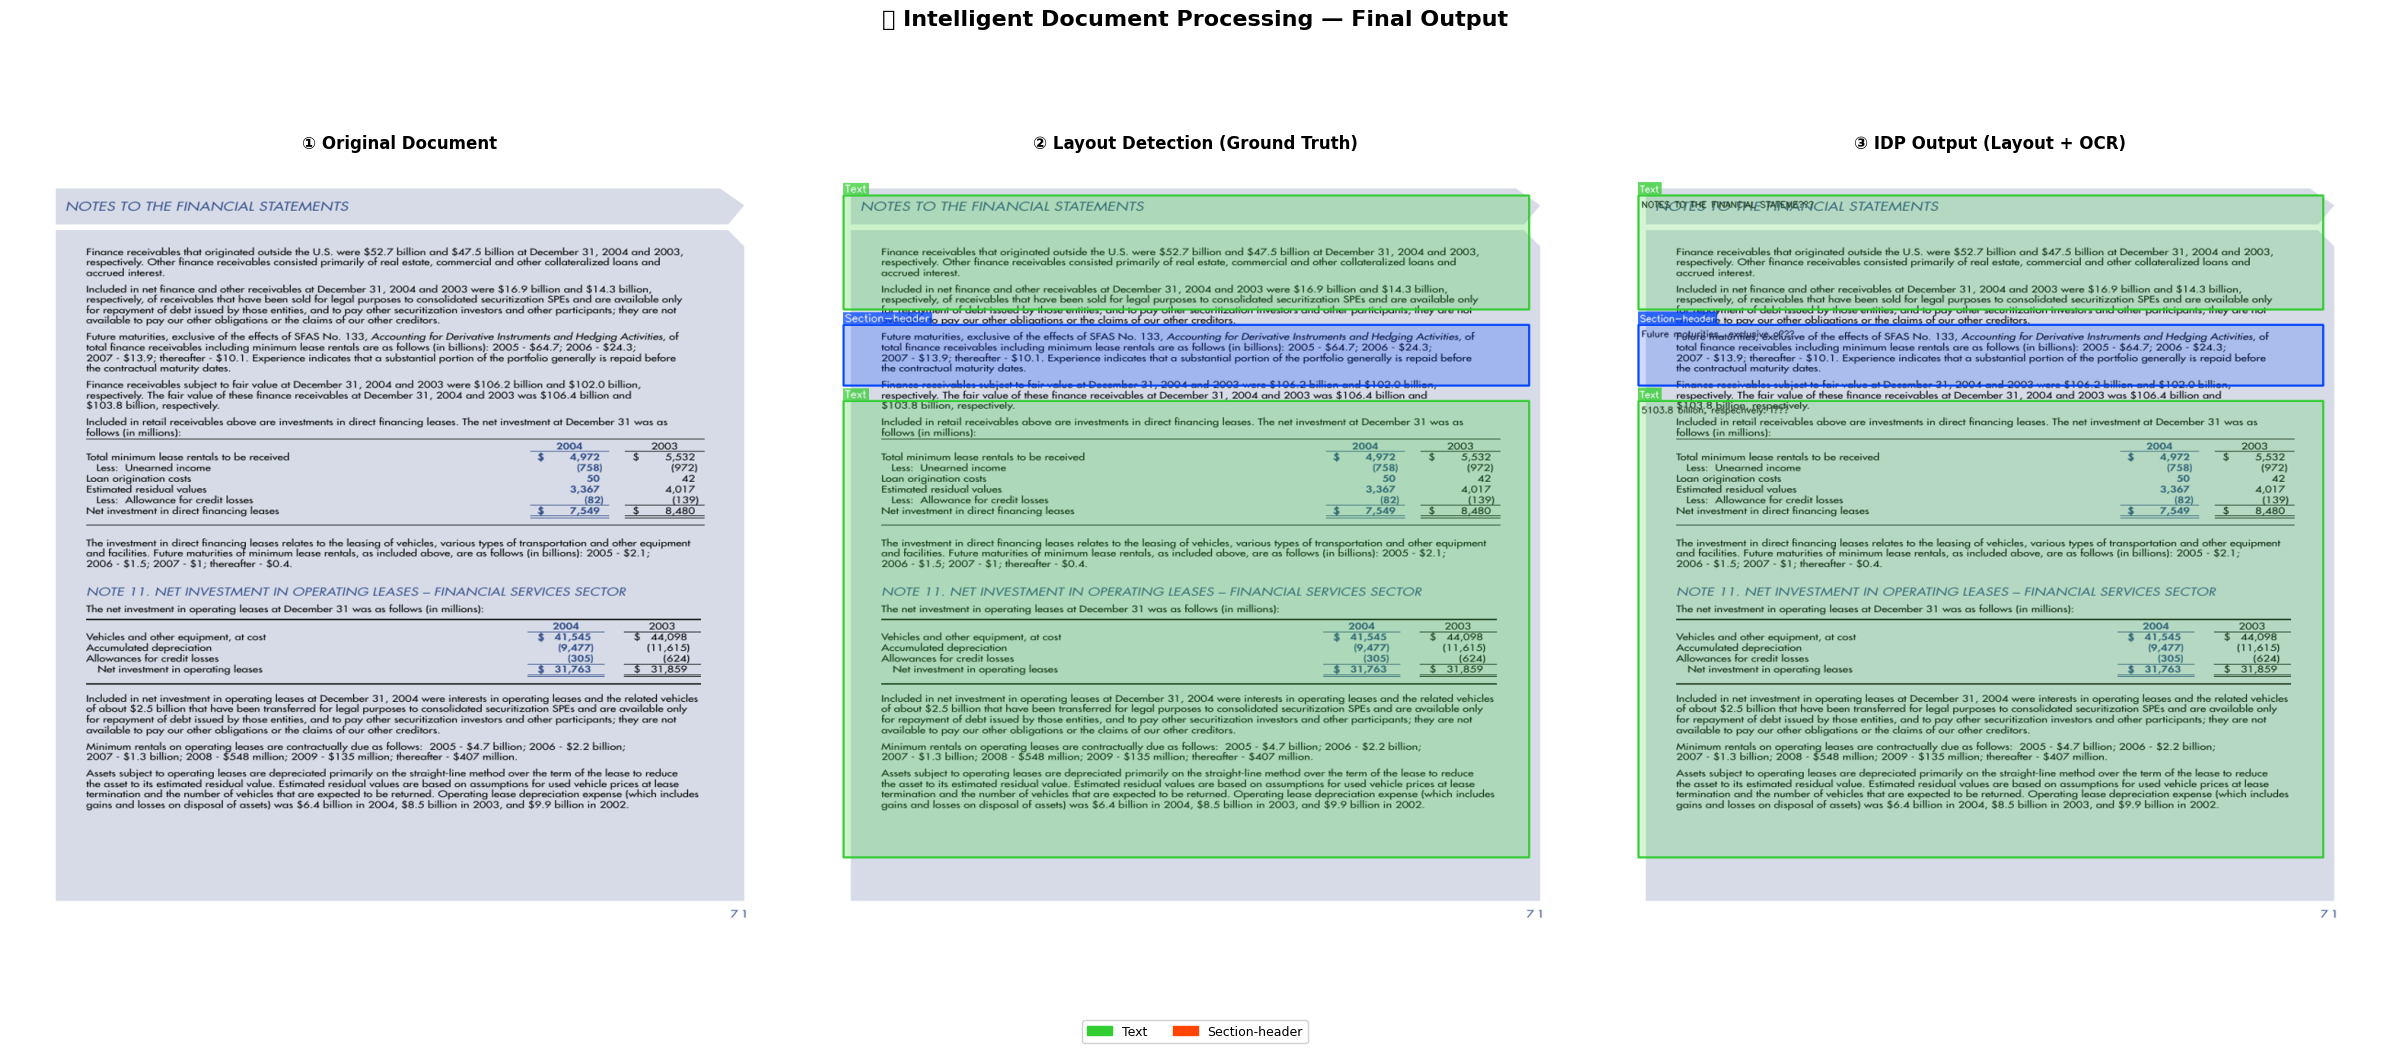

✅ Final visualization saved to output\idp_final_output.png


In [16]:
def draw_ocr_overlay(img_array, df, max_text_len=30):
    """
    Draw bounding boxes + OCR text preview on document image.
    """
    img_bgr   = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
    overlay   = img_bgr.copy()
    annotated = img_bgr.copy()

    for _, row in df.iterrows():
        x, y, w, h = int(row['x']), int(row['y']), int(row['width']), int(row['height'])
        color      = CATEGORY_COLORS.get(row['category'], (180, 180, 180))
        text       = row['ocr_text']
        text_prev  = (text[:max_text_len] + '…') if len(text) > max_text_len else text

        # Semi-transparent fill
        cv2.rectangle(overlay, (x, y), (x+w, y+h), color, -1)
        # Solid border
        cv2.rectangle(annotated, (x, y), (x+w, y+h), color, 2)

        # Category label (top-left)
        label = f"{row['category']}"
        (lw, lh), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)
        cv2.rectangle(annotated, (x, y-lh-8), (x+lw+4, y), color, -1)
        cv2.putText(annotated, label, (x+2, y-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1, cv2.LINE_AA)

        # OCR text inside box
        if text_prev and row['category'] not in SKIP_OCR_CATS:
            cv2.putText(annotated, text_prev, (x+4, y+16),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.38, (30, 30, 30), 1, cv2.LINE_AA)

    cv2.addWeighted(overlay, 0.2, annotated, 0.8, 0, annotated)
    return cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)


final_viz = draw_ocr_overlay(raw_img, df_structured)

# 3-panel figure
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

axes[0].imshow(raw_img)
axes[0].set_title('① Original Document', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(annotated_img)
axes[1].set_title('② Layout Detection (Ground Truth)', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(final_viz)
axes[2].set_title('③ IDP Output (Layout + OCR)', fontsize=12, fontweight='bold')
axes[2].axis('off')

used_cats = df_structured['category'].unique()
patches = [mpatches.Patch(color=np.array(CATEGORY_COLORS.get(c, (128,128,128)))/255, label=c)
           for c in used_cats]
fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=9,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('🏁 Intelligent Document Processing — Final Output',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
plt.savefig(output_dir / 'idp_final_output.png', dpi=150, bbox_inches='tight')

plt.show()
print(f"✅ Final visualization saved to {output_dir / 'idp_final_output.png'}")

## 📊 Step 15 — Dataset-Level Analytics

Let's compute aggregate statistics across a larger batch of documents.

📊 Computing dataset-level statistics...


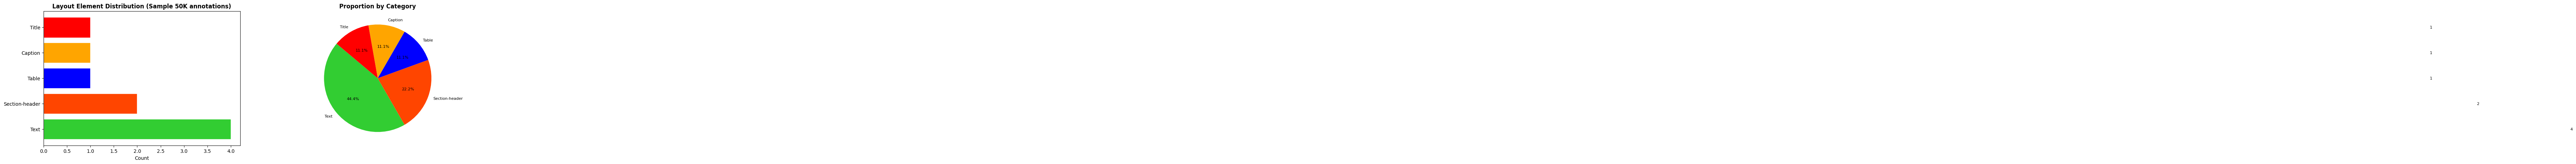


📈 Category Counts:
      Category  Count
          Text      4
Section-header      2
         Table      1
       Caption      1
         Title      1


In [17]:
# Analyze annotation distribution across all images (no image loading needed)
print("📊 Computing dataset-level statistics...")

all_ann_ids = coco.getAnnIds()
all_anns    = coco.loadAnns(all_ann_ids[:50000])  # sample for speed

cat_counts = {}
for ann in all_anns:
    name = CAT_LOOKUP.get(ann['category_id'], 'Unknown')
    cat_counts[name] = cat_counts.get(name, 0) + 1

df_cat = pd.DataFrame(list(cat_counts.items()),
                      columns=['Category', 'Count']).sort_values('Count', ascending=False)

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors = [np.array(CATEGORY_COLORS.get(c, (128,128,128)))/255
          for c in df_cat['Category']]
bars = axes[0].barh(df_cat['Category'], df_cat['Count'], color=colors, edgecolor='white')
axes[0].set_title('Layout Element Distribution (Sample 50K annotations)',
                  fontweight='bold')
axes[0].set_xlabel('Count')
for bar, count in zip(bars, df_cat['Count']):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{count:,}', va='center', fontsize=8)

# Pie chart
axes[1].pie(df_cat['Count'], labels=df_cat['Category'], colors=colors,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 8})
axes[1].set_title('Proportion by Category', fontweight='bold')

plt.tight_layout()
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
plt.savefig(output_dir / 'dataset_analytics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📈 Category Counts:")
print(df_cat.to_string(index=False))

## 📈 Step 16 — OCR Confidence Analysis

Analyze OCR confidence scores across different layout element types.

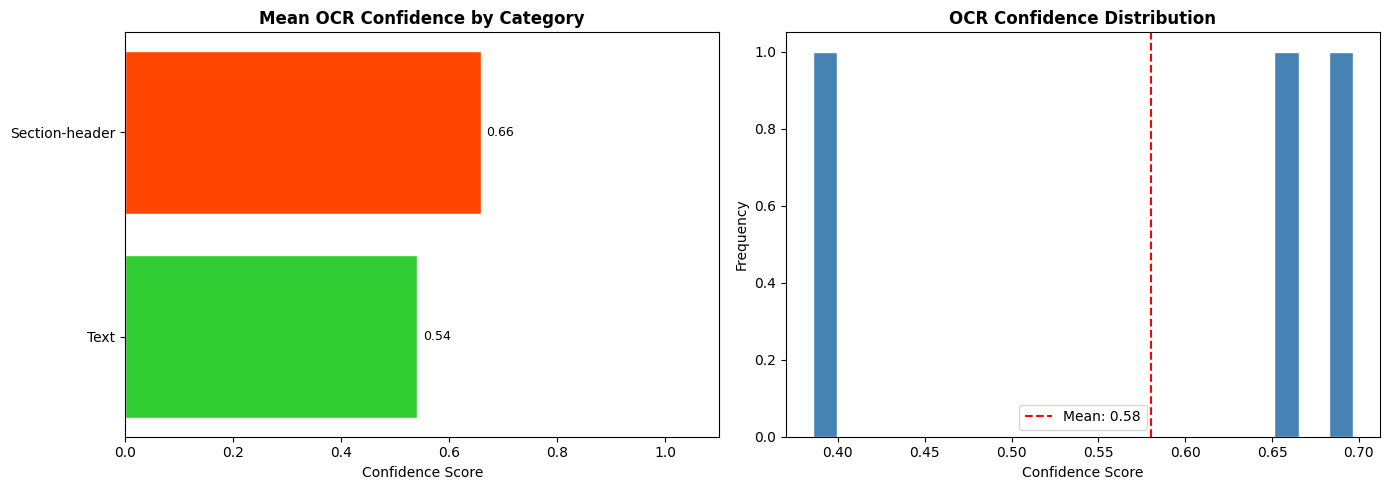

✅ OCR confidence analysis complete!


In [18]:
# OCR confidence by category
df_text = df_structured[df_structured['ocr_confidence'] > 0].copy()

if len(df_text) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confidence by category
    cat_conf = df_text.groupby('category')['ocr_confidence'].agg(['mean', 'min', 'max'])
    cat_conf_sorted = cat_conf.sort_values('mean', ascending=True)
    colors_bar = [np.array(CATEGORY_COLORS.get(c, (128,128,128)))/255
                  for c in cat_conf_sorted.index]
    bars = axes[0].barh(cat_conf_sorted.index, cat_conf_sorted['mean'],
                        color=colors_bar, edgecolor='white')
    axes[0].set_xlim(0, 1.1)
    axes[0].set_title('Mean OCR Confidence by Category', fontweight='bold')
    axes[0].set_xlabel('Confidence Score')
    for bar, val in zip(bars, cat_conf_sorted['mean']):
        axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.2f}', va='center', fontsize=9)

    # Confidence distribution histogram
    axes[1].hist(df_text['ocr_confidence'], bins=20, color='steelblue',
                 edgecolor='white', rwidth=0.9)
    axes[1].axvline(df_text['ocr_confidence'].mean(), color='red',
                    linestyle='--', label=f"Mean: {df_text['ocr_confidence'].mean():.2f}")
    axes[1].set_title('OCR Confidence Distribution', fontweight='bold')
    axes[1].set_xlabel('Confidence Score')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()

    plt.tight_layout()
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    plt.savefig(output_dir / 'ocr_confidence_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ OCR confidence analysis complete!")
else:
    print("⚠️  No OCR results with confidence > 0 for this image.")

## 💡 Step 17 — Process Multiple Documents (Batch Mode)

Scale the pipeline to process multiple document pages at once and save a combined JSON output.

In [19]:
def process_document(img_id, reader, coco, cat_lookup, color_lookup, skip_ocr_cats, img_base_dir, base_dir):
    """Full IDP pipeline for a single document image."""
    img_info    = coco.loadImgs([img_id])[0]
    annotations = get_annotations_for_image(img_id)

    try:
        raw_img = load_image(img_info)
    except FileNotFoundError:
        return None

    ocr_res = []
    for ann in annotations:
        cat_name = cat_lookup.get(ann['category_id'], 'Unknown')
        if cat_name in skip_ocr_cats:
            text, conf = '[non-text]', 0.0
        else:
            text, conf = ocr_region(raw_img, ann['bbox'])
        ocr_res.append({
            'category'  : cat_name,
            'bbox'      : ann['bbox'],
            'ocr_text'  : text.strip(),
            'confidence': round(conf, 4)
        })

    return {
        'image_id'  : img_id,
        'file_name' : img_info['file_name'],
        'width'     : img_info['width'],
        'height'    : img_info['height'],
        'elements'  : ocr_res
    }


# Process a batch of N documents
BATCH_SIZE   = 5
batch_ids    = random.sample(img_ids, min(BATCH_SIZE, len(img_ids)))
batch_results = []

print(f"🔄 Processing batch of {BATCH_SIZE} documents...")
for img_id in tqdm(batch_ids, desc='Batch Progress'):
    result = process_document(img_id, reader, coco, CAT_LOOKUP, COLOR_LOOKUP,
                               SKIP_OCR_CATS, IMG_DIR, BASE_DIR)
    if result:
        batch_results.append(result)

# Save batch JSON
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
BATCH_OUTPUT = output_dir / 'idp_batch_output.json'
with open(BATCH_OUTPUT, 'w', encoding='utf-8') as f:
    json.dump({'batch_size': len(batch_results), 'documents': batch_results},
              f, ensure_ascii=False, indent=2)

print(f"\n✅ Batch processing complete!")
print(f"   Processed : {len(batch_results)} documents")
print(f"   Saved to  : {BATCH_OUTPUT}")
print(f"   File size : {os.path.getsize(BATCH_OUTPUT)/1024:.1f} KB")

🔄 Processing batch of 5 documents...


Batch Progress: 100%|██████████| 4/4 [00:58<00:00, 14.67s/it]


✅ Batch processing complete!
   Processed : 4 documents
   Saved to  : output\idp_batch_output.json
   File size : 14.2 KB


## ⬇️ Step 18 — Download Output Files

Download all output artifacts from this notebook to your local machine.

In [20]:
import zipfile
import subprocess
import platform

# Bundle all outputs
output_dir = Path("output")
output_files = [
    output_dir / f'idp_output_{TARGET_IMG_ID}.json',
    output_dir / 'idp_batch_output.json',
    output_dir / 'annotated_layout.png',
    output_dir / 'idp_final_output.png',
    output_dir / 'dataset_analytics.png',
    output_dir / 'ocr_confidence_analysis.png',
]
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
zip_path = output_dir / 'IDP_DocLayNet_Outputs.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    for fp in output_files:
        if os.path.exists(fp):
            zf.write(fp, os.path.basename(fp))
            print(f"   ✅ Added: {os.path.basename(fp)}")
        else:
            print(f"   ⚠️  Not found: {fp}")

print(f"\n📦 Zip created: {zip_path}")
print(f"   📍 Location: {zip_path.absolute()}")

# Open the output folder in file explorer (Windows/Mac/Linux compatible)
try:
    if platform.system() == 'Windows':
        os.startfile(str(output_dir.absolute()))
    elif platform.system() == 'Darwin':  # macOS
        subprocess.run(['open', str(output_dir.absolute())])
    else:  # Linux
        subprocess.run(['xdg-open', str(output_dir.absolute())])
    print(f"✅ Opened output folder in file explorer")
except Exception as e:
    print(f"⚠️  Could not open folder automatically: {e}")
    print(f"   Please navigate to: {output_dir.absolute()}")

   ✅ Added: idp_output_1.json
   ✅ Added: idp_batch_output.json
   ✅ Added: annotated_layout.png
   ✅ Added: idp_final_output.png
   ✅ Added: dataset_analytics.png
   ✅ Added: ocr_confidence_analysis.png

📦 Zip created: output\IDP_DocLayNet_Outputs.zip
   📍 Location: d:\Mini Project\enterprise_doc_automation-main\output\IDP_DocLayNet_Outputs.zip
✅ Opened output folder in file explorer


## 🏁 Summary & Conclusion

---

### ✅ What We Built

| Component | Technology Used | Purpose |
|-----------|----------------|----------|
| Dataset | DocLayNet (COCO format) | Document layout annotations |
| Annotation Parser | pycocotools | Load & query COCO JSON |
| Image Processing | OpenCV, Pillow | Crop regions, draw boxes |
| OCR Engine | EasyOCR | Extract text from regions |
| Data Structuring | pandas, Python dicts | Merge layout + text |
| Output | JSON | Structured document data |
| Visualization | matplotlib | Annotated document views |

### 🔄 The IDP Pipeline

```
Document Image
      ↓
Layout Detection  ←── DocLayNet annotations (COCO JSON)
      ↓
Region Cropping   ←── OpenCV
      ↓
OCR Extraction    ←── EasyOCR
      ↓
Semantic Structuring ← Python
      ↓
JSON Output       ←── Structured, searchable document
```

### 🚀 Possible Extensions

1. **Fine-tune a layout detection model** (e.g. LayoutLMv3, DINO) on DocLayNet
2. **Table extraction** using specialized table-parsing models
3. **Named Entity Recognition** on the extracted text
4. **Build a search index** (Elasticsearch, FAISS) over extracted document text
5. **Deploy as a REST API** using FastAPI + Docker
6. **Integrate with document management systems** (SharePoint, Google Drive)

---

> 🎓 **BTech CSE Project** | Enterprise Document Automation — IDP  
> Built with DocLayNet + EasyOCR + OpenCV + pycocotools

In [21]:
import pickle

# Create models directory if it doesn't exist
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Save the EasyOCR Reader
reader_pkl = models_dir / 'easyocr_reader.pkl'
with open(reader_pkl, 'wb') as f:
    pickle.dump(reader, f)
print(f"✅ EasyOCR Reader saved: {reader_pkl}")
print(f"   Size: {os.path.getsize(reader_pkl) / (1024**2):.1f} MB")

# Save processed results
results_pkl = models_dir / 'processing_results.pkl'
results_data = {
    'ocr_results': ocr_results,
    'df_structured': df_structured,
    'document_structure': document_structure,
    'df_ann': df_ann,
    'annotations': annotations,
    'TARGET_IMG_ID': TARGET_IMG_ID,
    'img_info': img_info
}
with open(results_pkl, 'wb') as f:
    pickle.dump(results_data, f)
print(f"\n✅ Processing Results saved: {results_pkl}")
print(f"   Size: {os.path.getsize(results_pkl) / 1024:.1f} KB")
print(f"   Contains: ocr_results, df_structured, document_structure, annotations")

# Save configuration
config_pkl = models_dir / 'pipeline_config.pkl'
config_data = {
    'CATEGORY_COLORS': CATEGORY_COLORS,
    'CAT_LOOKUP': CAT_LOOKUP,
    'COLOR_LOOKUP': COLOR_LOOKUP,
    'SKIP_OCR_CATS': SKIP_OCR_CATS,
    'IMG_DIR': str(IMG_DIR),
    'BASE_DIR': str(BASE_DIR)
}
with open(config_pkl, 'wb') as f:
    pickle.dump(config_data, f)
print(f"\n✅ Pipeline Configuration saved: {config_pkl}")
print(f"   Size: {os.path.getsize(config_pkl) / 1024:.1f} KB")

print(f"\n📦 All pickle files saved to: {models_dir.absolute()}")
print("\n🔄 To load pickle files in a new session:")
print(f"   with open('models/easyocr_reader.pkl', 'rb') as f:")
print(f"       reader = pickle.load(f)")
print(f"   with open('models/processing_results.pkl', 'rb') as f:")
print(f"       results_data = pickle.load(f)")

✅ EasyOCR Reader saved: models\easyocr_reader.pkl
   Size: 87.0 MB

✅ Processing Results saved: models\processing_results.pkl
   Size: 12.7 KB
   Contains: ocr_results, df_structured, document_structure, annotations

✅ Pipeline Configuration saved: models\pipeline_config.pkl
   Size: 0.6 KB

📦 All pickle files saved to: d:\Mini Project\enterprise_doc_automation-main\models

🔄 To load pickle files in a new session:
   with open('models/easyocr_reader.pkl', 'rb') as f:
       reader = pickle.load(f)
   with open('models/processing_results.pkl', 'rb') as f:
       results_data = pickle.load(f)
